In [23]:
# Load libraries
import pandas as pd # data manipulation
from pathlib import Path # Locate script directory
import numpy as np # vectorized math


In [24]:
# load dataset 

# get the directory where the current script is saved
dir = Path.cwd()

# point to data file (go up into workflow and down into data)
data_path = dir.parent / 'data' / 'train.csv'

# load csv
df1 = pd.read_csv(data_path)

In [25]:
# view shape info
df1.shape

(891, 12)

In [26]:
# duplicate info count 
df1.duplicated().sum()

np.int64(0)

In [27]:
# review data types (helps avoids data mining issue later downstream)
df1.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [28]:
# check for null values 
df1.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [29]:
# remove null values (In this cell, instead of removing nan values we will turn the column into a signal itself -> "Unkwnown")

df1['Cabin'] = df1['Cabin'].fillna('Unknown')

In [30]:
# replace null values with average age (mean)

mean = df1['Age'].mean().astype(int)

df1['Age'] = df1['Age'].fillna(mean)

In [31]:
 # replace null values with most frequent qualatative value (mode)

mode = df1['Embarked'].value_counts().max()

df1['Embarked'] = df1['Embarked'].fillna(mode)

In [32]:
# check results of null removal

df1.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [33]:
# remove "Name" column 
df1 = df1.drop(columns = ['Name'])

In [34]:
# summary statistics 
df1.describe(include=['number']).T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,891.0,29.560236,13.005010,0.42,22.0000,29.0000,35.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [35]:
#                                   --- Visualization Phase--- 
import seaborn as sns 
import matplotlib.pyplot as plt

<Axes: >

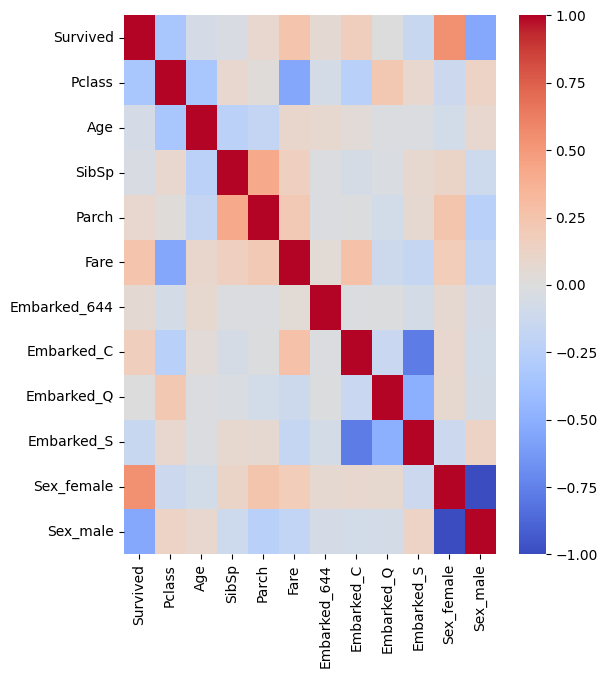

In [36]:
# Create a correlation heatmap

# drop the ID column... this variable has no use in training, will effect the visualization 
df_drop = df1.drop(columns= ['PassengerId']) 

# Create boolean columns for categorical features 
df_dummy = pd.get_dummies(df1[['Embarked', 'Sex']])

# merge boolean dataframe with original
df1 = df_drop.merge(df_dummy, left_index= True, right_index= True)

# compute correlation matrix for numeric values only 
corr = df1.select_dtypes(include = ['number', 'bool']).corr() # grab all numbers and boolean columns and store into corr object

# create map
plt.figure(figsize= (6,7)) # visualization size 
sns.heatmap(corr, annot = False, cmap= 'coolwarm', fmt = '.2f' ) # correation matrix plot 

In [37]:
df1.shape

(891, 16)

<Axes: >

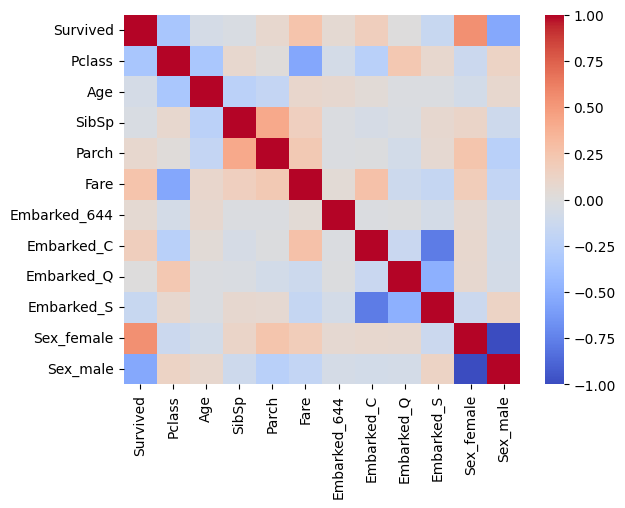

In [38]:
sns.heatmap(corr, annot = False, cmap= 'coolwarm', fmt = '.2f' ) # correation matrix plot 

In [39]:
# numeric correlation
df1.corr(numeric_only= True)

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked_644,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male
Survived,1.000000,-0.338481,-0.067814,-0.035322,0.081629,0.257307,0.060095,0.168240,0.003650,-0.155660,0.543351,-0.543351
Pclass,-0.338481,1.000000,-0.334974,0.083081,0.018443,-0.549500,-0.074282,-0.243292,0.221009,0.081720,-0.131900,0.131900
Age,-0.067814,-0.334974,1.000000,-0.232978,-0.176486,0.093706,0.074589,0.031303,-0.021093,-0.021999,-0.082949,0.082949
SibSp,-0.035322,0.083081,-0.232978,1.000000,0.414838,0.159651,-0.022508,-0.059528,-0.026354,0.070941,0.114631,-0.114631
Parch,0.081629,0.018443,-0.176486,0.414838,1.000000,0.216225,-0.022467,-0.011069,-0.081228,0.063036,0.245489,-0.245489
Fare,0.257307,-0.549500,0.093706,0.159651,0.216225,1.000000,0.045646,0.269335,-0.117216,-0.166603,0.182333,-0.182333
Embarked_644,0.060095,-0.074282,0.074589,-0.022508,-0.022467,0.045646,1.000000,-0.022864,-0.014588,-0.076588,0.064296,-0.064296
Embarked_C,0.168240,-0.243292,0.031303,-0.059528,-0.011069,0.269335,-0.022864,1.000000,-0.148258,-0.778359,0.082853,-0.082853
Embarked_Q,0.003650,0.221009,-0.021093,-0.026354,-0.081228,-0.117216,-0.014588,-0.148258,1.000000,-0.496624,0.074115,-0.074115
Embarked_S,-0.155660,0.081720,-0.021999,0.070941,0.063036,-0.166603,-0.076588,-0.778359,-0.496624,1.000000,-0.125722,0.125722


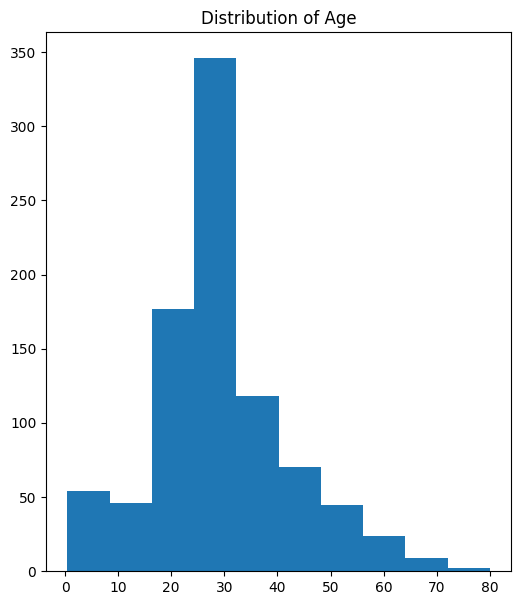

In [40]:
# distrbution of age 
plt.figure(figsize=(6,7))
plt.hist(x= df1['Age'], density= False, )
plt.title('Distribution of Age')
plt.show() 

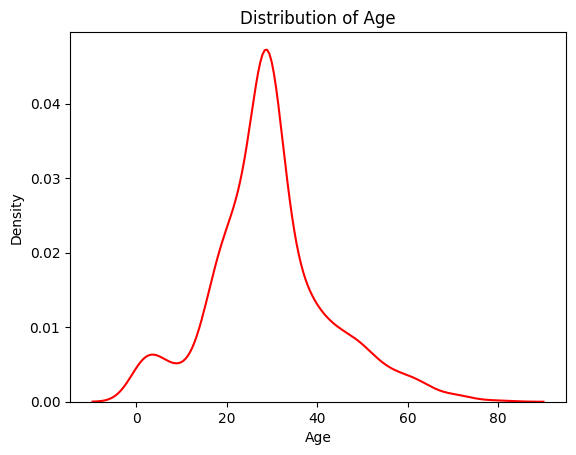

In [41]:
# Distribution of Age with smooth =
sns.kdeplot(data = df1, x = 'Age', color= 'red')
plt.title('Distribution of Age')
plt.show()

<function matplotlib.pyplot.title(label: 'str', fontdict: 'dict[str, Any] | None' = None, loc: "Literal['left', 'center', 'right'] | None" = None, pad: 'float | None' = None, *, y: 'float | None' = None, **kwargs) -> 'Text'>

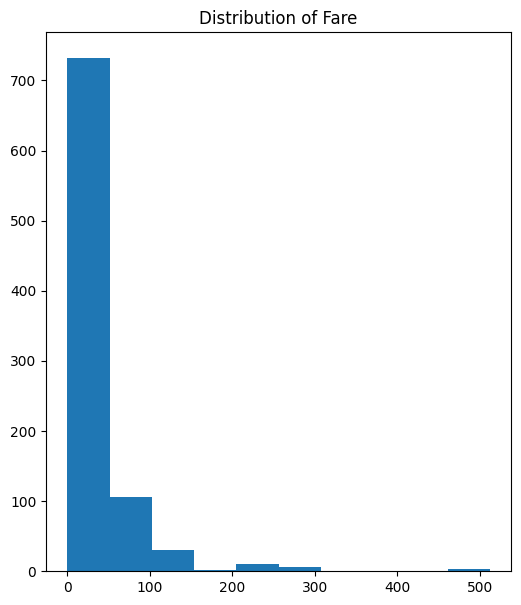

In [42]:
# Distribution of Fare (Passenger Price)
plt.figure(figsize=(6,7)) 
plt.hist(x = df1['Fare'], density= False)
plt.title('Distribution of Fare')
plt.title

<Axes: xlabel='Fare', ylabel='Density'>

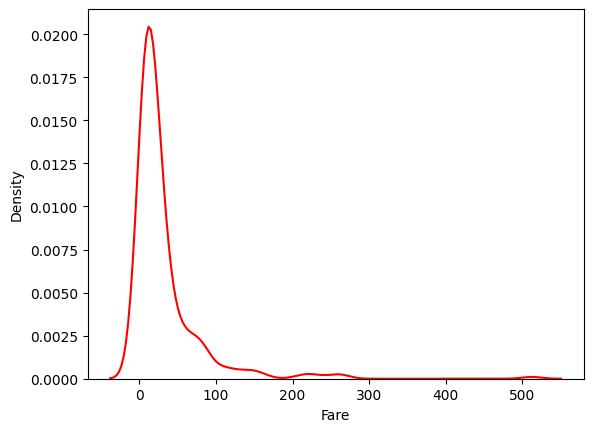

In [43]:
# Distribution of Fare with smoothing 
sns.kdeplot(df1, x = 'Fare', color = 'red')

In [44]:
df1

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Embarked_644,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male
0,0,3,male,22.0,1,0,A/5 21171,7.2500,Unknown,S,False,False,False,True,False,True
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,False,True,False,False,True,False
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,False,False,False,True,True,False
3,1,1,female,35.0,1,0,113803,53.1000,C123,S,False,False,False,True,True,False
4,0,3,male,35.0,0,0,373450,8.0500,Unknown,S,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,211536,13.0000,Unknown,S,False,False,False,True,False,True
887,1,1,female,19.0,0,0,112053,30.0000,B42,S,False,False,False,True,True,False
888,0,3,female,29.0,1,2,W./C. 6607,23.4500,Unknown,S,False,False,False,True,True,False
889,1,1,male,26.0,0,0,111369,30.0000,C148,C,False,True,False,False,False,True


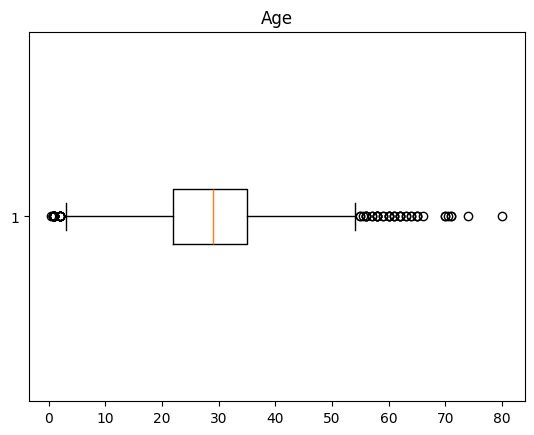

In [45]:
# Look for high leverage data plots within input variables 

# whisker plot 
plt.boxplot(df1['Age'], vert = False)
plt.title('Age')
plt.show()

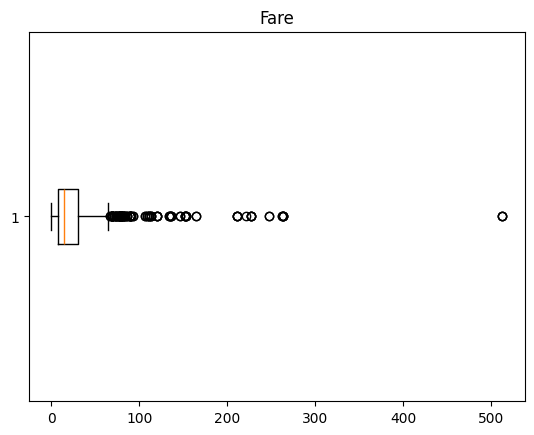

In [46]:
# Look for high leverage values in X 

# boxplot 
plt.boxplot(df1['Fare'], vert = False)
plt.title("Fare")
plt.show()

In [47]:
# The Fare varibale has data points far from the residual 
# To avoid the regression line being pull towards them and distorting the decision boudary, I will log transform the columns indiviually

# Fare log transformation 
df1['Fare'] = np.log1p(df1['Fare'])


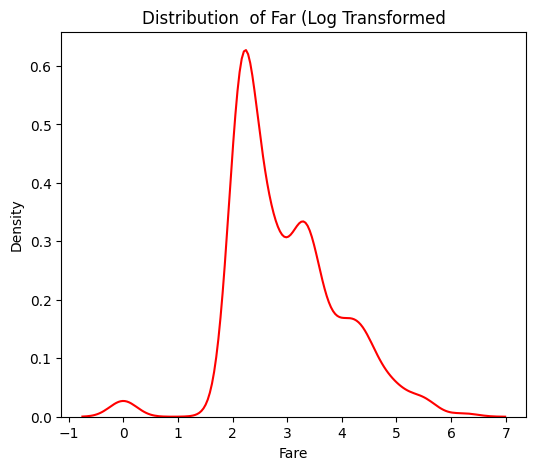

In [48]:
# View distribution for Fare variable 
plt.figure(figsize= (6,5)) 
sns.kdeplot(data = df1, x = 'Fare', color= 'red')
plt.title('Distribution  of Far (Log Transformed')
plt.show()

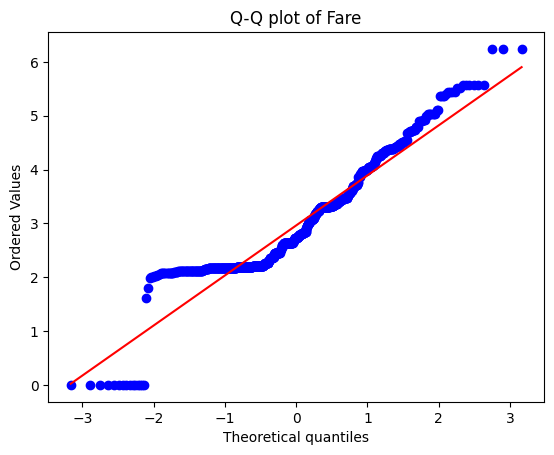

In [49]:
# Let's view the plot using a Q-Q plot 

import scipy.stats as stats
stats.probplot(df1['Fare'], dist = 'norm', plot = plt)
plt.title('Q-Q plot of Fare')
plt.show()

In [50]:
# turn high cardinality varibles into meaningful patterns
# Model can learn from the categories based on the mean of each category coupled with the target variable 

from sklearn.preprocessing import TargetEncoder # library 

# intialize encoder (including cross validation prohibits data leakage)
encoder = TargetEncoder(smooth = 'auto', cv = 5, shuffle = True, random_state= 42)

# store variables into X and Y obejects
X = df1[['Cabin']]
Y = df1['Survived']

# fit to transform 
df1['Cabin_encoded'] = encoder.fit_transform(X, Y)

In [51]:
# scale numerical values (This is leads to model converging much faster)
from sklearn.preprocessing import StandardScaler

# create instance
scaler = StandardScaler()

# store columns in a object
X = df1[['Age']]
X1 = df1[['Fare']]

# fit to transform columns
df1['Age'] = scaler.fit_transform(X)
df1['Fare'] = scaler.fit_transform(X1)

In [52]:
# remove ticket number column (Weak or meanless variable)
df1 = df1.drop(columns=['Ticket'])

In [53]:
# remove uneccesary columns (Stings won't fit in training downstream)
df1 = df1.drop(columns=['Sex'])
df1 = df1.drop(columns=['Cabin'])
df1 = df1.drop(columns=["Embarked"])

In [54]:
df1

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked_644,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male,Cabin_encoded
0,0,3,-0.581659,1,0,-0.879741,False,False,False,True,False,True,0.303217
1,1,1,0.649327,1,0,1.361220,False,True,False,False,True,False,0.382889
2,1,3,-0.273913,0,0,-0.798540,False,False,False,True,True,False,0.298863
3,1,1,0.418517,1,0,1.062038,False,False,False,True,True,False,0.000000
4,0,3,0.418517,0,0,-0.784179,False,False,False,True,False,True,0.303215
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,-0.196976,0,0,-0.333698,False,False,False,True,False,True,0.297779
887,1,1,-0.812469,0,0,0.487082,False,False,False,True,True,False,0.384292
888,0,3,-0.043103,1,2,0.242007,False,False,False,True,True,False,0.298863
889,1,1,-0.273913,0,0,0.487082,False,True,False,False,False,True,0.384292


In [55]:
# Feature Engineneering Phase 
# (Later we will test t-test coefficients to view if feature is statistically significant in predicting target)

# Interaction features  
df1['interaction1'] = (df1['SibSp'] * df1['Parch'])
df1['interaction2'] = (df1['SibSp'] * df1['Fare'])
df1['interaction3'] = (df1['Parch'] * df1['Fare'])
df1['interaction4'] = (df1['Age'] * df1['Fare'])
df1['interaction5'] = (df1['Pclass'] * df1['Fare'])
df1['interaction6'] = (df1['Sex_female'] * df1['Fare'])
df1['interaction7'] = (df1['Sex_male'] * df1['Fare'])


# Ratio Features 
df1['Ratio1'] = (df1['Age'] / df1['Fare'])
df1['Ratio2'] = (df1['SibSp'] / df1['Fare'])
df1['Ratio3'] = (df1['Parch'] / df1['Fare'])
df1['Ratio4'] = (df1['Sex_female'] / df1['Fare'])
df1['Ratio5'] = (df1['Sex_male'] / df1['Fare'])





In [56]:
# save the dataset with engineered features to CSV
df1.to_csv('uncut_feat.csv', index=False)


In [57]:
# new dataset with updated features 

# find the data file 
data_path = dir.parent / 'Data' / 'Dominant_feat.csv'

# load data in object 
df2 = pd.read_csv(data_path)

# view result 
df2.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked_644,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male,Cabin_encoded,interaction4,interaction5,interaction6,interaction7,Ratio1,Ratio4,Ratio5
0,0,3,-0.581659,1,0,-0.879741,False,False,False,True,False,True,0.303217,0.511709,-2.639222,-0.000000,-0.879741,0.661171,-0.000000,-1.136699
1,1,1,0.649327,1,0,1.361220,False,True,False,False,True,False,0.382889,0.883877,1.361220,1.361220,0.000000,0.477018,0.734635,0.000000
2,1,3,-0.273913,0,0,-0.798540,False,False,False,True,True,False,0.298863,0.218730,-2.395620,-0.798540,-0.000000,0.343017,-1.252285,-0.000000
3,1,1,0.418517,1,0,1.062038,False,False,False,True,True,False,0.000000,0.444481,1.062038,1.062038,0.000000,0.394070,0.941586,0.000000
4,0,3,0.418517,0,0,-0.784179,False,False,False,True,False,True,0.303215,-0.328192,-2.352538,-0.000000,-0.784179,-0.533701,-0.000000,-1.275219


In [58]:
# Training Phase 
# import neccessary library from sklearn
from sklearn.model_selection import train_test_split

# inputs/features (rop target feature to avoid data leakage)
X = df2.drop(columns=['Survived'])

# Target variable 
Y = df2['Survived']

# 70/30 split 
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 0.3, shuffle= True, random_state= 42)


In [73]:
# import sklearn libraries for downstream modeling workflow 
from sklearn.metrics import confusion_matrix, classification_report # numeric performance indicators

In [74]:
# Let's try to improve upon the model performance by using K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier # uses distances to classify which class a data point belongs in 

# instantiation process
KNN = KNeighborsClassifier(n_neighbors=5)

# fit the data on the model 
KNN.fit(X_train, Y_train)

# predictions
KNN_pred = KNN.predict(X_test)

# performance results 
print(f'Classification Report: {classification_report(Y_test, KNN_pred)}')
print(f'Confusion Matric: {confusion_matrix(Y_test, KNN_pred)}')

Classification Report:               precision    recall  f1-score   support

           0       0.81      0.87      0.84       157
           1       0.80      0.70      0.75       111

    accuracy                           0.80       268
   macro avg       0.80      0.79      0.79       268
weighted avg       0.80      0.80      0.80       268

Confusion Matric: [[137  20]
 [ 33  78]]


In [72]:
# Find the best optimal settings for K-Nearest Neighbors 
# import gridsearchcv to locate the best paramaters for the model
from sklearn.model_selection import GridSearchCV

params = {'n_neighbors': [1, 5, 10, 15, 20], 
          'weights': ['uniform', 'distance'], 
          'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'], 
          'leaf_size': [10, 20, 30, 40], }
# instantiation process
KNN_best = GridSearchCV(estimator = KNN, param_grid= params, cv = 5, verbose = 5, scoring= 'recall')

# fit data on the model 
KNN_best.fit(X_train, Y_train)

# predictions 
KNN_pred = KNN_best.predict(X_test)

# performance results
print(f'Classification Report:{classification_report(Y_test, KNN_pred)}')
print(f'Best Settings: {(KNN_best.best_estimator_)}')

Fitting 5 folds for each of 160 candidates, totalling 800 fits
[CV 1/5] END algorithm=auto, leaf_size=10, n_neighbors=1, weights=uniform;, score=0.702 total time=   0.0s
[CV 2/5] END algorithm=auto, leaf_size=10, n_neighbors=1, weights=uniform;, score=0.717 total time=   0.0s
[CV 3/5] END algorithm=auto, leaf_size=10, n_neighbors=1, weights=uniform;, score=0.478 total time=   0.0s
[CV 4/5] END algorithm=auto, leaf_size=10, n_neighbors=1, weights=uniform;, score=0.696 total time=   0.0s
[CV 5/5] END algorithm=auto, leaf_size=10, n_neighbors=1, weights=uniform;, score=0.739 total time=   0.0s
[CV 1/5] END algorithm=auto, leaf_size=10, n_neighbors=1, weights=distance;, score=0.702 total time=   0.0s
[CV 2/5] END algorithm=auto, leaf_size=10, n_neighbors=1, weights=distance;, score=0.717 total time=   0.0s
[CV 3/5] END algorithm=auto, leaf_size=10, n_neighbors=1, weights=distance;, score=0.478 total time=   0.0s
[CV 4/5] END algorithm=auto, leaf_size=10, n_neighbors=1, weights=distance;, s

In [75]:
# Modeling Phase (Classification)
from sklearn.svm import SVC # support vector model 

# instantiation process
svm = SVC()

# fit the data on the model
svm.fit(X_train, Y_train)

# predictios
Y_predictions = svm.predict(X_test)

# predictions results
Y_predictions

# Evaluate model performance results 
print(f'Classification Report {classification_report(Y_test, Y_predictions)}')
print(f'Confusion Matrix {confusion_matrix(Y_test, Y_predictions)}')

Classification Report               precision    recall  f1-score   support

           0       0.81      0.86      0.83       157
           1       0.78      0.71      0.75       111

    accuracy                           0.80       268
   macro avg       0.80      0.79      0.79       268
weighted avg       0.80      0.80      0.80       268

Confusion Matrix [[135  22]
 [ 32  79]]


In [ ]:
# Search to find the best optimal settings 
params = {'kernel': ['linear', 'sigmoid', 'rbf', 'poly'], 
          'C': [1, 10, 100, 500, 1000], 
          'gamma': [1, 0.1, 0.001, 0.0001, 0.00001], 
}

# instantiation process
SVM_Best = GridSearchCV(estimator= svm, param_grid= params, cv = 5, scoring = 'recall')

# fit data on model 
SVM_Best.fit(X_train, Y_train)

# predictions
SVM_pred = SVM_Best.predict(X_test)

# evaluate performance results 
print(f'Classification Report: {classification_report(Y_test, SVM_pred)}')
print(f'Confusion Matrix: {confusion_matrix(Y_test, SVM_pred)}')
print(f'Best settings: {SVM_Best.best_estimator_}')

In [ ]:
# lets build a ensemble model to truly implement the correct model needed
from sklearn.linear_model import LogisticRegression # Logistic Regression
from sklearn.ensemble import RandomForestClassifier # Random forest 
from sklearn.ensemble import VotingClassifier # Voting Model 

# define indiviual model 
cf1 = LogisticRegression()
cf2 = RandomForestClassifier(n_estimators= 50)
cf3 = SVC(probability= True)

# create ensemble 
ensemble = VotingClassifier(
    estimators= [('lr', cf1), ('rf', cf2), ('svc', cf3)],
    voting = 'soft'
)

# fit data onto ensemble
ensemble = ensemble.fit(X_train, Y_train)

# Predictions 
ensemble_pred = ensemble.predict(X_test)

# results 
ensemble_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0])

In [63]:
# evalute the performnace of models 
print(f'classification_report {classification_report(Y_test, ensemble_pred)}')
print(f'confusion matrix {confusion_matrix(Y_test, ensemble_pred)}')

classification_report               precision    recall  f1-score   support

           0       0.82      0.90      0.86       157
           1       0.84      0.73      0.78       111

    accuracy                           0.83       268
   macro avg       0.83      0.81      0.82       268
weighted avg       0.83      0.83      0.83       268

confusion matrix [[141  16]
 [ 30  81]]


In [64]:
name  = ensemble.named_estimators_.items()
score = ensemble(X_test, Y_test)
print(f'{'lr'} {score:.4f}')

TypeError: 'VotingClassifier' object is not callable